Change directory to "group04-team02-1"

## Needleman-Wunsch-Alignment


This algorithm is used to calculate a biologically relevant global alignment score of the amino acid sequences. 
Its main advantage is that insertions or deletions at the beginning or end of the alignment are taken into account in the score calculation. It explores all possible alignments between two sequences, A of length 𝑚 and B of length 𝑛, and finds the best possible match based on a scoring matrix.
In this case, the BLOSUM62 matrix is used as a substitution matrix. It is commonly used for sequence alignment of proteins with less than 62% similarity.
Gaps are penalized (opening and extending), allowing flexible alignment while still rewarding similarity. 

This script performs pairwise sequence alignments for all complementarity-determining regions (CDR_H1, CDR_H2, and CDR_H3) across antibody sequences derived from SARS-CoV-2, human, and influenza sources. For each CDR type, all possible sequence pairs are globally aligned using the BLOSUM62 substitution matrix and specified gap penalties. The resulting alignment scores are stored in two formats, which are saved as TSV files for further comparative analysis:
- a square matrix for each CDR region containing all pairwise scores
- a long-format table listing unique pairs and their scores. 

In [ ]:
import pandas as pd
from Bio import pairwise2
from Bio.Align import substitution_matrices
import numpy as np

# 1. Load the scoring matrix (BLOSUM62)
blosum62 = substitution_matrices.load("BLOSUM62")

# 2. Read the TSV files for the three organisms
sars_df = pd.read_csv(r'generated/cdrs/seq/corona_cdr_seq.tsv', sep="\t")
human_df = pd.read_csv(r'generated/cdrs/seq/human_cdr_seq.tsv', sep="\t")
influenza_df = pd.read_csv(r'generated/cdrs/seq/influenza_cdr_seq.tsv', sep="\t")

# 3. Extract CDR sequences from each DataFrame and label them
def extract_cdrs(df, label):
    cdrs = []
    for _, row in df.iterrows():
        cdrs.append({
            "id": f"{label}_{row['pdb']}",
            "CDR_H1": row["CDR_H1"],
            "CDR_H2": row["CDR_H2"],
            "CDR_H3": row["CDR_H3"]
        })
    return cdrs

sars_cdrs = extract_cdrs(sars_df, "SARS")
human_cdrs = extract_cdrs(human_df, "Human")
influenza_cdrs = extract_cdrs(influenza_df, "Flu")

# 4. Combine all CDRs into one list
all_cdrs = sars_cdrs + human_cdrs + influenza_cdrs
all_ids = [entry["id"] for entry in all_cdrs]

# 5. Define a function to align two sequences and return the alignment score
def align_pair(seq1, seq2):
    aln = pairwise2.align.globalds(seq1, seq2, blosum62, -10, -0.5, one_alignment_only=True)
    score = aln[0].score
    return score

# 6. Process each CDR type (H1, H2, H3) separately
cdr_types = ["CDR_H1", "CDR_H2", "CDR_H3"]

# Dictionaries to store results as matrices and long-format data
matrix_results = {}
long_format_rows = []

for cdr in cdr_types:
    # Initialize an empty score matrix
    score_matrix = np.zeros((len(all_ids), len(all_ids)))
    
    print(f"\n Processing {cdr}")
    
    # Compute all pairwise alignments
    for i in range(len(all_cdrs)):
        for j in range(len(all_cdrs)):
            id1 = all_ids[i]
            id2 = all_ids[j]
            seq1 = all_cdrs[i][cdr]
            seq2 = all_cdrs[j][cdr]
            score = align_pair(seq1, seq2)
            
            score_matrix[i, j] = score
            
            if j > i:
                # Store only upper triangle in long format
                long_format_rows.append({
                    "CDR": cdr,
                    "ID1": id1,
                    "ID2": id2,
                    "Score": score
                })
    
    # Convert score matrix to DataFrame and store it
    df_matrix = pd.DataFrame(score_matrix, index=all_ids, columns=all_ids)
    matrix_results[cdr] = df_matrix
    
    # Save matrix as TSV file
    outfile = f"{cdr.lower()}_alignment_matrix.tsv"
    df_matrix.to_csv(outfile, sep="\t")
    print(f"Saved matrix to {outfile}")

# 7. Save all pairwise results in long-format TSV
df_long = pd.DataFrame(long_format_rows)
df_long.to_csv("all_cdr_alignment_long.tsv", sep="\t", index=False)
print("Saved long-format file to all_cdr_alignment_long.tsv")




=== Processing CDR_H1 ===
Saved matrix to cdr_h1_alignment_matrix.tsv

=== Processing CDR_H2 ===
Saved matrix to cdr_h2_alignment_matrix.tsv

=== Processing CDR_H3 ===
Saved matrix to cdr_h3_alignment_matrix.tsv
Saved long-format file to all_cdr_alignment_long.tsv


### PCA & Clustering

This step intends to summarize the CDR alignment matrices into per-sequence feature profiles. The raw matrices are high-dimensional and not directly suitable for comparative analyses or visualization. Therefore, it is important to creat a interpretable feature representation for every sequence. In this case, mean alignment scores to each organism group. The features from all three CDRs are merged into a single table 'cdr_per_sequence_mean_alignment_features.tsv'

In [12]:
import pandas as pd
import numpy as np

# Paths to your CDR alignment matrices
cdr_files = {
    "CDR_H1": r'generated/cdrs/seq/cdr_h1_alignment_matrix.tsv',
    "CDR_H2": r'generated/cdrs/seq/cdr_h2_alignment_matrix.tsv',
    "CDR_H3": r'generated/cdrs/seq/cdr_h3_alignment_matrix.tsv',
}

# Initialize empty dictionary to hold feature DataFrames
feature_dict = {}

# Loop over CDRs
for cdr_name, file_path in cdr_files.items():
    print(f"\nProcessing {cdr_name}...")

    # Load matrix
    df = pd.read_csv(file_path, sep="\t", index_col=0)

    # Extract IDs
    ids = df.index.tolist()
    organisms = [x.split("_")[0] for x in ids]
    unique_orgs = sorted(set(organisms))
    id_to_org = dict(zip(ids, organisms))

    # Initialize output DataFrame
    feature_df = pd.DataFrame(index=ids)

    # For each organism group, compute the mean alignment score per sequence
    for target_org in unique_orgs:
        ids_target = [id for id in ids if id_to_org[id] == target_org]

        # Mean score to all sequences in target_org
        mean_scores = df.loc[:, ids_target].mean(axis=1)

        # Add column
        feature_df[f"{cdr_name}_mean_to_{target_org}"] = mean_scores

    # Store this DataFrame
    feature_dict[cdr_name] = feature_df

# Merge all CDR feature DataFrames horizontally
combined_features = pd.concat(feature_dict.values(), axis=1)

# Optionally, add organism label
combined_features["Organism"] = [x.split("_")[0] for x in combined_features.index]

# Save to TSV
outfile = r'archive/cdr_per_sequence_mean_alignment_features.tsv'
combined_features.to_csv(outfile, sep="\t")

print(f"\nSaved per-sequence feature matrix to {outfile}")
print(combined_features.head())



Processing CDR_H1...

Processing CDR_H2...

Processing CDR_H3...

Saved per-sequence feature matrix to archive/cdr_per_sequence_mean_alignment_features.tsv
           CDR_H1_mean_to_Flu  CDR_H1_mean_to_Human  CDR_H1_mean_to_SARS  \
SARS_9cci               14.41             19.767810            17.031746   
SARS_9ccj                8.21              2.984169             3.297619   
SARS_9bj2                3.83              6.535620             8.564815   
SARS_8z6r               13.89             20.730871            17.510582   
SARS_8z6s               13.89             20.730871            17.510582   

           CDR_H2_mean_to_Flu  CDR_H2_mean_to_Human  CDR_H2_mean_to_SARS  \
SARS_9cci              -3.905             -1.283641             0.379630   
SARS_9ccj               2.630             -1.664908             2.544974   
SARS_9bj2              -7.430             -7.573879            -9.486772   
SARS_8z6r              -1.785              1.175462             2.431217   
SARS_8

This code performs a Principal Component Analysis on the scaled mean CDR alignment scores of antibody sequences to reduce the data to two dimensions. Each point in the scatter plot represents an antibody, colored by its organism of origin. The aim of PCA is to help visualize whether the antibodies cluster differently by organism based on their CDR similarity patterns.

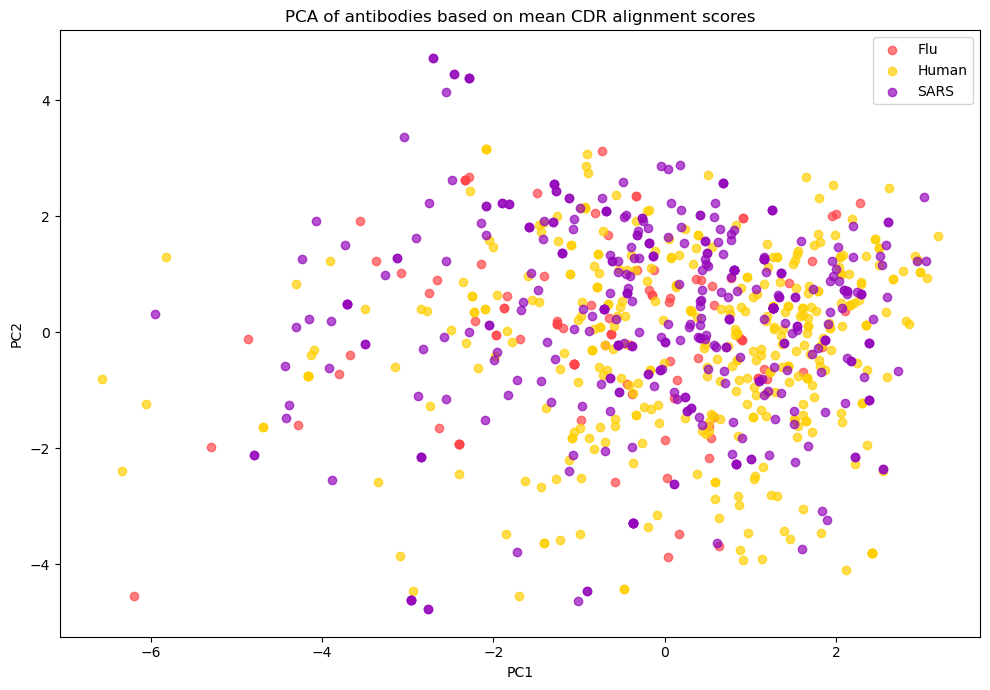

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load the table
df = pd.read_csv(
    r'archive/cdr_per_sequence_mean_alignment_features.tsv',
    sep="\t", index_col=0)

# Separate features and labels
X = df.drop(columns="Organism").values
y = df["Organism"].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10,7))
palette = {'SARS': '#9509BB', 'Human': '#FFCF01', 'Flu': '#FF474B'}
for label in np.unique(y):
    plt.scatter(
        X_pca[y==label,0],
        X_pca[y==label,1],
        label=label,
        color=palette[label],   
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of antibodies based on mean CDR alignment scores")
plt.legend()
plt.tight_layout()
plt.show()

This code takes the PCA-transformed data and applies K-means clustering to group the points into three clusters. Each cluster ideally corresponds to one of the organism groups in the dataset, meaning K = 3 is chosen. After clustering, it creates a scatter plot of the first two principal components, coloring each point according to its assigned cluster. 
This approach intends to find natural grouping of the sequences based on their features, in this case the CDR per sequence mean alignment.

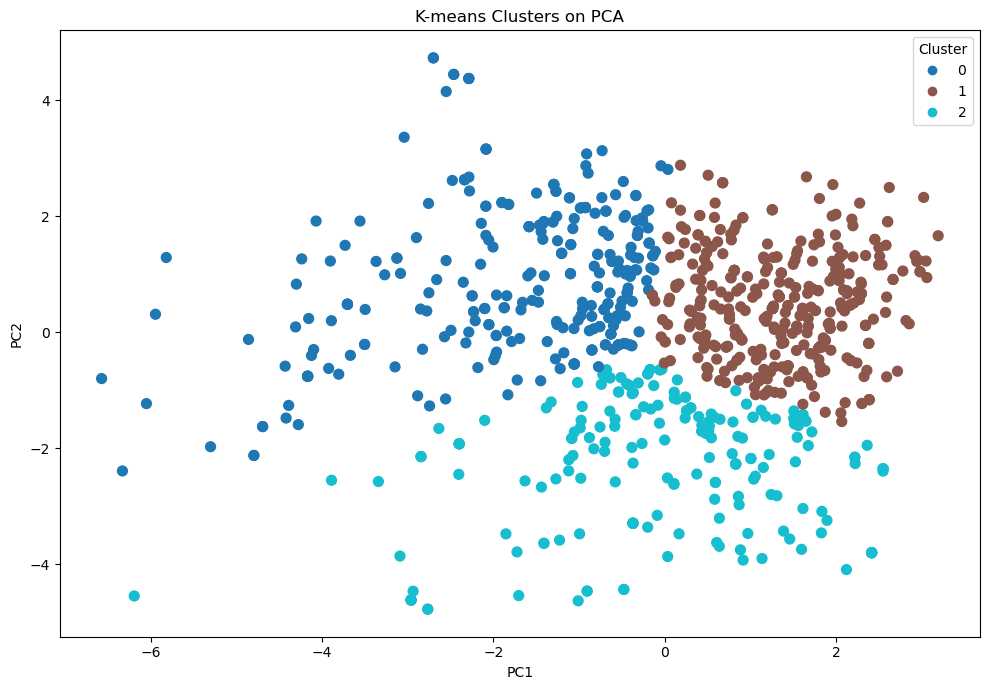

In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.cm import get_cmap

# K -means clustering, choose k = 3 for three organisms
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)

plt.figure(figsize=(10,7))
scatter = plt.scatter(
    X_pca[:,0], 
    X_pca[:,1], 
    c=labels, 
    cmap="tab10",  
    s=50
)
plt.title("K-means Clusters on PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

# Simple legend
plt.legend(*scatter.legend_elements(), title="Cluster")

plt.tight_layout()
plt.show()

These clustering results suggest that the sequences from the different organisms do not form distinct groups based on the principal components analysis. This means that clustering like K-means on these PCA components might not be sufficient to fully differentiate between the organisms. If the sequences among the different organisms are more similar or intermixed than expected is to be determined with further statistical methods. 

### Heatmap & Statistical test

In this part, the intention is to take sequence alignment data for the three CDR regions and analyze it one by one.

The code calculates the average alignment score between every pair of organism groups. This results three different summary matrices showing how similar sequences from one organism are to those from another in that particular CDR region. It saves these summary matrices to files and prints them out.

In [13]:
import pandas as pd
import numpy as np

# Define your CDR regions and paths
cdr_files = {
    "CDR_H1": r'generated/cdrs/seq/cdr_h1_alignment_matrix.tsv',
    "CDR_H2": r'generated/cdrs/seq/cdr_h2_alignment_matrix.tsv',
    "CDR_H3": r'generated/cdrs/seq/cdr_h3_alignment_matrix.tsv',
}

# Loop over each CDR
for cdr_name, file_path in cdr_files.items():
    print(f"\nProcessing {cdr_name}...")

    # Load matrix
    df = pd.read_csv(file_path, sep="\t", index_col=0)

    # Extract IDs
    ids = df.index.tolist()
    organisms = [x.split("_")[0] for x in ids]
    unique_orgs = sorted(set(organisms))
    id_to_org = dict(zip(ids, organisms))

    print(f"Found organism groups: {unique_orgs}")

    # Initialize output mean matrix
    mean_matrix = pd.DataFrame(index=unique_orgs, columns=unique_orgs, dtype=float)

    # Compute mean alignment scores per organism pair
    for org1 in unique_orgs:
        ids1 = [id for id in ids if id_to_org[id] == org1]
        for org2 in unique_orgs:
            ids2 = [id for id in ids if id_to_org[id] == org2]

            submatrix = df.loc[ids1, ids2].values
            mean_score = np.mean(submatrix)
            mean_matrix.loc[org1, org2] = mean_score

    # Save this mean matrix
    outfile = rf'archive/{cdr_name}_alignment_means.tsv'
    mean_matrix.to_csv(outfile, sep="\t")
    print(f"Saved mean matrix to {outfile}")

    # Optionally display
    print(mean_matrix)



Processing CDR_H1...
Found organism groups: ['Flu', 'Human', 'SARS']
Saved mean matrix to archive/CDR_H1_alignment_means.tsv
             Flu      Human       SARS
Flu    10.685100  12.320475  10.730833
Human  12.320475  17.881705  15.281390
SARS   10.730833  15.281390  14.035140

Processing CDR_H2...
Found organism groups: ['Flu', 'Human', 'SARS']
Saved mean matrix to archive/CDR_H2_alignment_means.tsv
            Flu     Human      SARS
Flu   -0.207700 -0.935013 -0.543783
Human -0.935013  0.096560 -0.410967
SARS  -0.543783 -0.410967  1.172756

Processing CDR_H3...
Found organism groups: ['Flu', 'Human', 'SARS']
Saved mean matrix to archive/CDR_H3_alignment_means.tsv
           Flu     Human      SARS
Flu   -1.27030 -4.579420 -3.438770
Human -4.57942 -1.755028 -2.468484
SARS  -3.43877 -2.468484 -1.274005


In [14]:
import pandas as pd

# Loading each CDR matrix, TSV files are read
cdr1 = pd.read_csv(r'archive/CDR_H1_alignment_means.tsv', sep="\t", index_col=0)
cdr2 = pd.read_csv(r'archive/CDR_H2_alignment_means.tsv', sep="\t", index_col=0)
cdr3 = pd.read_csv(r'archive/CDR_H3_alignment_means.tsv', sep="\t", index_col=0)

This code creates heatmaps that show the mean alignment scores between organisms for each CDR region. For example, it shows how similar Flu sequences are to Human or SARS sequences on average. Each cell in the heatmap represents this mean similarity, with color gradients making patterns stand out clearly. High scores are shown in warm colors, low scores in cool colors. By plotting all three CDR regions, you can immediately spot which pairs of organisms have higher or lower alignment similarity.

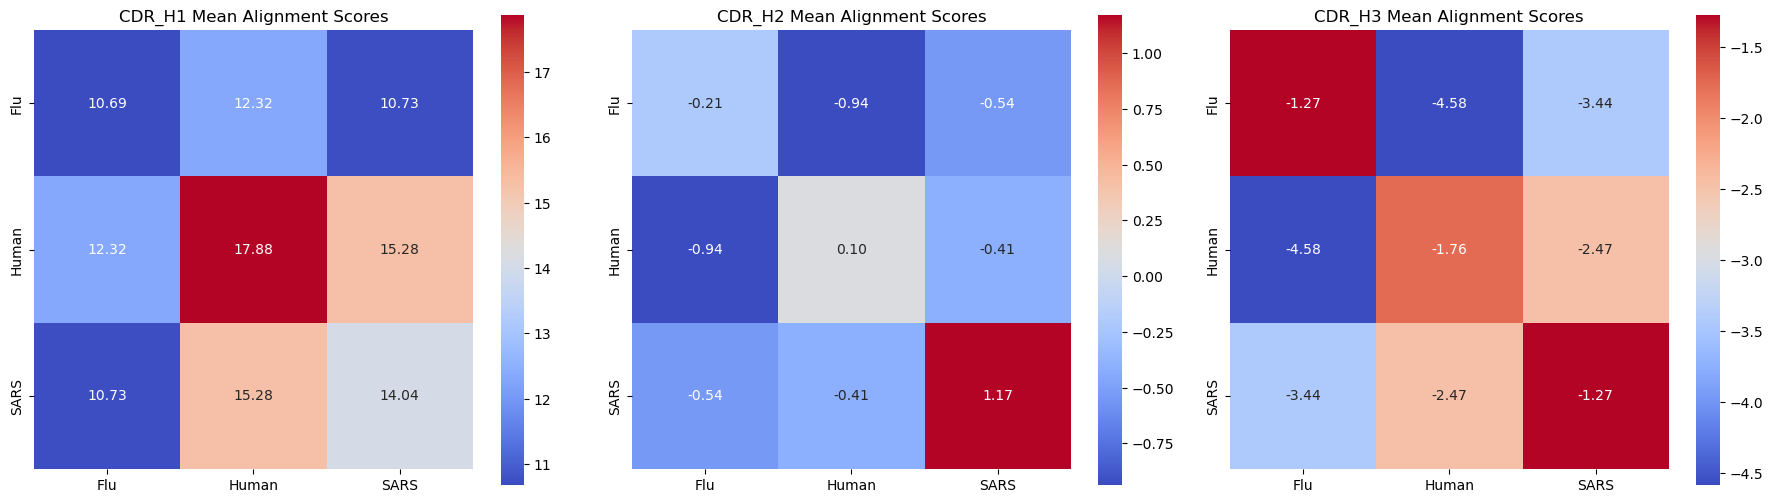

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# CDR H1
sns.heatmap(cdr1, annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=axes[0])
axes[0].set_title("CDR_H1 Mean Alignment Scores")

# CDR H2
sns.heatmap(cdr2, annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=axes[1])
axes[1].set_title("CDR_H2 Mean Alignment Scores")

# CDR H3
sns.heatmap(cdr3, annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=axes[2])
axes[2].set_title("CDR_H3 Mean Alignment Scores")

plt.tight_layout()
plt.show()


This heatmap roughly shows that:
- CDR-H1 shows the highest sequence similarity, with sequences within a single organism being most similar, especially in Homo sapiens.

- CDR-H2 and CDR-H3 are significantly more variable and differ greatly between organisms.

This section quantifies how similar sequences are within the same organism group (the diagonal of the matrix) versus between different groups (the off-diagonal cells). The code calculates:
- The average similarity score among sequences from the same organism.
- The average score across sequences from different organisms.
- The ratio between them.

If the ratio is greater than 1, it means sequences are more similar within groups than between groups, which means that organism-specific sequence patterns do exist. This intends to understand whether alignment is driven by the organism of origin.

In [4]:
import numpy as np

def summarize_within_between(df):
    groups = df.index
    within = []
    between = []

    for i in range(len(groups)):
        for j in range(len(groups)):
            val = df.iloc[i,j]
            if i == j:
                within.append(val)
            else:
                between.append(val)
    
    print("Within-group mean: {:.3f}".format(np.mean(within)))
    print("Between-group mean: {:.3f}".format(np.mean(between)))
    print("Ratio (within / between): {:.3f}".format(np.mean(within)/np.mean(between)))

print("=== CDR_H1 ===")
summarize_within_between(cdr1)

print("\n=== CDR_H2 ===")
summarize_within_between(cdr2)

print("\n=== CDR_H3 ===")
summarize_within_between(cdr3)


=== CDR_H1 ===
Within-group mean: 14.201
Between-group mean: 12.778
Ratio (within / between): 1.111

=== CDR_H2 ===
Within-group mean: 0.354
Between-group mean: -0.630
Ratio (within / between): -0.562

=== CDR_H3 ===
Within-group mean: -1.433
Between-group mean: -3.496
Ratio (within / between): 0.410


These results show how similar the CDR sequences are within organisms compared to between different organisms:

CDR_H1 has a higher average similarity within groups (14.2) than between groups (12.8), with a ratio > 1, suggesting CDR_H1 is relatively conserved within organisms.

CDR_H2 and CDR_H3 have much lower within-group similarity and even lower between-group similarity, with CDR_H2 showing a negative ratio, indicating more variability or inconsistent alignment results.

CDR_H3 shows the lowest similarity scores overall, confirming it is the most variable region across and within organisms.

In summary, CDR_H1 is the most conserved, while CDR_H3 is highly diverse.

This part performs a Mann-Whitney U test comparing within-group scores to between-group scores. This is a non-parametric test that checks if the difference in similarity is statistically significant. If the p-value is below 0.05, one conclude that sequences within the same organism group have significantly different (typically higher) alignment scores than sequences across different organisms. 

In [5]:
from scipy.stats import mannwhitneyu

def test_within_vs_between(df, cdr_name):
    groups = df.index
    within = []
    between = []

    for i in range(len(groups)):
        for j in range(len(groups)):
            val = df.iloc[i,j]
            if i == j:
                within.append(val)
            else:
                between.append(val)
    
    u_stat, p_value = mannwhitneyu(within, between, alternative="two-sided")
    print(f"{cdr_name}: Mann-Whitney U = {u_stat:.3f}, p = {p_value:.3g}")
    if p_value < 0.05:
        print("➡️ Significant difference between within- and between-group alignment means.\n")
    else:
        print("➡️ No significant difference.\n")

print("=== Statistical Tests ===")
test_within_vs_between(cdr1, "CDR_H1")
test_within_vs_between(cdr2, "CDR_H2")
test_within_vs_between(cdr3, "CDR_H3")


=== Statistical Tests ===
CDR_H1: Mann-Whitney U = 10.000, p = 0.896
➡️ No significant difference.

CDR_H2: Mann-Whitney U = 18.000, p = 0.0262
➡️ Significant difference between within- and between-group alignment means.

CDR_H3: Mann-Whitney U = 18.000, p = 0.0262
➡️ Significant difference between within- and between-group alignment means.



These statistical test results assess whether the similarity scores within the same organism differ significantly from those between different organisms:

CDR_H1: The p-value (0.896) is high, meaning there is no significant difference between within- and between-group similarities. The alignment scores are similar regardless of organism.

CDR_H2 and CDR_H3: Both have p-values of 0.0262, which are statistically significant. This means there is a meaningful difference in similarity between sequences from the same organism and different organisms.

In conclusion, for comparing CDR sequences in this project, the use of the Needleman-Wunsch alignment algorithm proved to be a more optimal choice than simpler alignment methods. It allowed for a more precise assessment of pairwise similarity across CDR sequences.

In particular, the analysis revealed that CDR-H1 sequences tend to be more conserved within organisms, especially in Homo sapiens, while CDR-H2 and CDR-H3 are notably more variable, showing greater divergence both within and between groups.

It would have significantly enriched the analysis to apply a multiple sequence alignment (MSA) tool such as Clustal Omega. This would have enabled the identification of conserved positions across groups and organisms, providing deeper insights into evolutionary patterns and functional relevance. Unfortunately, due to system and compatibility issues, the integration of this MSA-tool into this project was not possible.